Understand where the model fails

Detect systematic bias

Decide what to fix (if anything)

In [11]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

MODEL_PATH = r"../data/interim/models/hgb_y_Assets_it900_lr0.03_d8.joblib"

model = joblib.load(MODEL_PATH)
print("Model loaded:", type(model))


Model loaded: <class 'dict'> <class 'dict'>


In [15]:
import os
from pathlib import Path
import pandas as pd

# Paths coming from ZenML split_step
val_path  = latest_run.steps["split_step"].outputs["val_path"][0].load()
test_path = latest_run.steps["split_step"].outputs["test_path"][0].load()

print("Raw val_path:", val_path)
print("Raw test_path:", test_path)
print("CWD:", os.getcwd())

def resolve_existing(p: str) -> str:
    p = str(p).replace("\\", "/")
    candidates = [
        Path(p),
        Path("..") / p,
        Path("..") / ".." / p,
        Path("..") / ".." / ".." / p,
    ]
    for c in candidates:
        if c.exists():
            return str(c)
    raise FileNotFoundError(f"Could not resolve path: {p} (tried {len(candidates)} candidates)")

val_path_resolved = resolve_existing(val_path)
test_path_resolved = resolve_existing(test_path)

print("Resolved val_path:", val_path_resolved)
print("Resolved test_path:", test_path_resolved)

df_eval = pd.read_parquet(val_path_resolved).copy()
df_eval["end"] = pd.to_datetime(df_eval["end"], errors="coerce")

print("df_eval shape:", df_eval.shape)
display(df_eval.head(3))


Raw val_path: data/interim/val.parquet data/interim/val.parquet
Raw test_path: data/interim/test.parquet data/interim/test.parquet
CWD: d:\balance-sheet-ml\notebooks d:\balance-sheet-ml\notebooks
Resolved val_path: ..\data\interim\val.parquet ..\data\interim\val.parquet
Resolved test_path: ..\data\interim\test.parquet ..\data\interim\test.parquet
df_eval shape: (9337, 113) (9337, 113)


,cik,end,Assets,AssetsCurrent,AssetsNoncurrent,Liabilities,LiabilitiesCurrent,LiabilitiesNoncurrent,StockholdersEquity,LiabilitiesAndStockholdersEquity,CashAndCashEquivalentsAtCarryingValue,CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents,AccountsReceivableNetCurrent,InventoryNet,PrepaidExpenseCurrent,PropertyPlantAndEquipmentNet,Goodwill,IntangibleAssetsNetExcludingGoodwill,DebtCurrent,LongTermDebt,LongTermDebtCurrent,AccountsPayableCurrent,AccruedLiabilitiesCurrent,RetainedEarningsAccumulatedDeficit,CommonStockValue,AdditionalPaidInCapital,AccumulatedOtherComprehensiveIncomeLossNetOfTax,Assets_lag1,AssetsCurrent_lag1,AssetsNoncurrent_lag1,Liabilities_lag1,LiabilitiesCurrent_lag1,LiabilitiesNoncurrent_lag1,StockholdersEquity_lag1,LiabilitiesAndStockholdersEquity_lag1,CashAndCashEquivalentsAtCarryingValue_lag1,CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents_lag1,AccountsReceivableNetCurrent_lag1,InventoryNet_lag1,PrepaidExpenseCurrent_lag1,PropertyPlantAndEquipmentNet_lag1,Goodwill_lag1,IntangibleAssetsNetExcludingGoodwill_lag1,DebtCurrent_lag1,LongTermDebt_lag1,LongTermDebtCurrent_lag1,AccountsPayableCurrent_lag1,AccruedLiabilitiesCurrent_lag1,RetainedEarningsAccumulatedDeficit_lag1,CommonStockValue_lag1,AdditionalPaidInCapital_lag1,AccumulatedOtherComprehensiveIncomeLossNetOfTax_lag1,y_Assets,y_Assets_is_log,y_AssetsCurrent,y_AssetsCurrent_is_log,y_AssetsNoncurrent,y_AssetsNoncurrent_is_log,y_Liabilities,y_Liabilities_is_log,y_LiabilitiesCurrent,y_LiabilitiesCurrent_is_log,y_LiabilitiesNoncurrent,y_LiabilitiesNoncurrent_is_log,y_StockholdersEquity,y_StockholdersEquity_is_log,y_LiabilitiesAndStockholdersEquity,y_LiabilitiesAndStockholdersEquity_is_log,y_CashAndCashEquivalentsAtCarryingValue,y_CashAndCashEquivalentsAtCarryingValue_is_log,y_CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents,y_CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents_is_log,y_AccountsReceivableNetCurrent,y_AccountsReceivableNetCurrent_is_log,y_InventoryNet,y_InventoryNet_is_log,y_PrepaidExpenseCurrent,y_PrepaidExpenseCurrent_is_log,y_PropertyPlantAndEquipmentNet,y_PropertyPlantAndEquipmentNet_is_log,y_Goodwill,y_Goodwill_is_log,y_IntangibleAssetsNetExcludingGoodwill,y_IntangibleAssetsNetExcludingGoodwill_is_log,y_DebtCurrent,y_DebtCurrent_is_log,y_LongTermDebt,y_LongTermDebt_is_log,y_LongTermDebtCurrent,y_LongTermDebtCurrent_is_log,y_AccountsPayableCurrent,y_AccountsPayableCurrent_is_log,y_AccruedLiabilitiesCurrent,y_AccruedLiabilitiesCurrent_is_log,y_RetainedEarningsAccumulatedDeficit,y_RetainedEarningsAccumulatedDeficit_is_log,y_CommonStockValue,y_CommonStockValue_is_log,y_AdditionalPaidInCapital,y_AdditionalPaidInCapital_is_log,y_AccumulatedOtherComprehensiveIncomeLossNetOfTax,y_AccumulatedOtherComprehensiveIncomeLossNetOfTax_is_log,cash_to_assets,current_assets_to_assets,liab_to_assets,equity_to_assets,current_liab_to_liab,ppe_to_assets,goodwill_to_assets,intangibles_to_assets,wc_to_assets,debt_to_assets,debt_to_equity
0,0000001750,2025-02-28,2.859100e+09,1.534800e+09,NaN,NaN,5.452000e+08,1.131300e+09,NaN,2.859100e+09,8.440000e+07,1.009000e+08,NaN,7.757000e+08,NaN,1.534000e+08,5.284000e+08,2.236000e+08,NaN,NaN,NaN,278900000.0,236700000.0,9.354000e+08,4.530000e+07,NaN,-1.210000e+07,2.849300e+09,1.498000e+09,NaN,NaN,5.583000e+08,1.109400e+09,NaN,2.849300e+09,6.170000e+07,8.250000e+07,NaN,7.900000e+08,NaN,1.670000e+08,5.432000e+08,2.273000e+08,NaN,NaN,NaN,291800000.0,258800000.0,9.443000e+08,4.530000e+07,NaN,-1.060000e+07,0.003434,1,0.024269,1,NaN,0,NaN,0,-0.023744,1,0.019548,1,NaN,0,0.003434,1,0.313283,1,0.201332,1,NaN,0,-0.018267,1,NaN,0,-0.084945,1,-0.027624,1,-0.016412,1,NaN,0,NaN,0,NaN,0,-0.045215,1,-0.089262,1,-0.00947,1,0.000000,1,NaN,0,-3.0,0,0.029520,0.536812,NaN,NaN,NaN,0.053653,0.184813,0.078206,0.346123,0.000000,NaN
1,0000001800,2025-03-31,8.144800e+10,2.315300e+10,NaN,3.263700e+10,1.300400e+10,NaN,4.881100e+10,8.144800e+10,6.532000e+09,6.532000e+09,7.327000e+09,6.639000e+09,NaN,1.093200e+10

In [16]:
TARGET = "y_Assets"

FEATURES = [
    c for c in df_eval.columns
    if c not in ["cik", "end"]
    and not c.startswith("y_")
]

print("Target:", TARGET)
print("n_features:", len(FEATURES))
print("First 15 features:", FEATURES[:15])


Target: y_Assets y_Assets
n_features: 61 61
First 15 features: ['Assets', 'AssetsCurrent', 'AssetsNoncurrent', 'Liabilities', 'LiabilitiesCurrent', 'LiabilitiesNoncurrent', 'StockholdersEquity', 'LiabilitiesAndStockholdersEquity', 'CashAndCashEquivalentsAtCarryingValue', 'CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents', 'AccountsReceivableNetCurrent', 'InventoryNet', 'PrepaidExpenseCurrent', 'PropertyPlantAndEquipmentNet', 'Goodwill'] ['Assets', 'AssetsCurrent', 'AssetsNoncurrent', 'Liabilities', 'LiabilitiesCurrent', 'LiabilitiesNoncurrent', 'StockholdersEquity', 'LiabilitiesAndStockholdersEquity', 'CashAndCashEquivalentsAtCarryingValue', 'CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents', 'AccountsReceivableNetCurrent', 'InventoryNet', 'PrepaidExpenseCurrent', 'PropertyPlantAndEquipmentNet', 'Goodwill']


In [19]:
import joblib

MODEL_PATH = r"../data/interim/models/hgb_y_Assets_it900_lr0.03_d8.joblib"
bundle = joblib.load(MODEL_PATH)

print("Loaded object type:", type(bundle))

# If it's a bundle dict, extract model + feature list if present
if isinstance(bundle, dict):
    print("Bundle keys:", list(bundle.keys()))
    
    # common keys
    model = bundle.get("model") or bundle.get("estimator") or bundle.get("regressor")
    feat_list = bundle.get("features") or bundle.get("feature_names") or bundle.get("columns")
    
    print("Extracted model type:", type(model))
    print("Has feature list?", feat_list is not None, "| n_features_in_bundle:", None if feat_list is None else len(feat_list))
else:
    model = bundle
    feat_list = None
    print("Model type:", type(model))


Loaded object type: <class 'dict'> <class 'dict'>
Bundle keys: ['model', 'features', 'target'] ['model', 'features', 'target']
Extracted model type: <class 'sklearn.pipeline.Pipeline'> <class 'sklearn.pipeline.Pipeline'>
Has feature list? True | n_features_in_bundle: 81 True | n_features_in_bundle: 81


In [23]:
# pull engineered artifacts from the feature_engineering_step
fe_out0 = latest_run.steps["feature_engineering_step"].outputs["output_0"][0].load()
fe_out1 = latest_run.steps["feature_engineering_step"].outputs["output_1"][0].load()
fe_out2 = latest_run.steps["feature_engineering_step"].outputs["output_2"][0].load()

print("feature_engineering outputs:")
print("out0 type:", type(fe_out0), "| value preview:", str(fe_out0)[:200])
print("out1 type:", type(fe_out1), "| value preview:", str(fe_out1)[:200])
print("out2 type:", type(fe_out2), "| value preview:", str(fe_out2)[:200])


feature_engineering outputs:
out0 type: <class 'str'> | value preview: data/interim/train_fe.parquet <class 'str'> | value preview: data/interim/train_fe.parquet
out1 type: <class 'str'> | value preview: data/interim/val_fe.parquet <class 'str'> | value preview: data/interim/val_fe.parquet
out2 type: <class 'str'> | value preview: data/interim/test_fe.parquet <class 'str'> | value preview: data/interim/test_fe.parquet


In [24]:
import pandas as pd
from pathlib import Path

def resolve_existing(p: str) -> str:
    p = str(p).replace("\\", "/")
    candidates = [Path(p), Path("..")/p, Path("..")/".."/p, Path("..")/".."/".."/p]
    for c in candidates:
        if c.exists():
            return str(c)
    raise FileNotFoundError(f"Could not resolve path: {p}")

val_fe_path = latest_run.steps["feature_engineering_step"].outputs["output_1"][0].load()
val_fe_path = resolve_existing(val_fe_path)

print("Resolved val_fe_path:", val_fe_path)

df_eval = pd.read_parquet(val_fe_path).copy()
df_eval["end"] = pd.to_datetime(df_eval["end"], errors="coerce")
print("df_eval (val_fe) shape:", df_eval.shape)

# quick sanity: missing features vs bundle
FEATURES = bundle["features"]
missing = [c for c in FEATURES if c not in df_eval.columns]
print("Missing features in val_fe:", len(missing))
if len(missing):
    print("Example missing:", missing[:10])

display(df_eval.head(3))


Resolved val_fe_path: ..\data\interim\val_fe.parquet ..\data\interim\val_fe.parquet
df_eval (val_fe) shape: (9337, 157) (9337, 157)
Missing features in val_fe: 0 0


,cik,end,Assets,AssetsCurrent,AssetsNoncurrent,Liabilities,LiabilitiesCurrent,LiabilitiesNoncurrent,StockholdersEquity,LiabilitiesAndStockholdersEquity,CashAndCashEquivalentsAtCarryingValue,CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents,AccountsReceivableNetCurrent,InventoryNet,PrepaidExpenseCurrent,PropertyPlantAndEquipmentNet,Goodwill,IntangibleAssetsNetExcludingGoodwill,DebtCurrent,LongTermDebt,LongTermDebtCurrent,AccountsPayableCurrent,AccruedLiabilitiesCurrent,RetainedEarningsAccumulatedDeficit,CommonStockValue,AdditionalPaidInCapital,AccumulatedOtherComprehensiveIncomeLossNetOfTax,Assets_lag1,AssetsCurrent_lag1,AssetsNoncurrent_lag1,Liabilities_lag1,LiabilitiesCurrent_lag1,LiabilitiesNoncurrent_lag1,StockholdersEquity_lag1,LiabilitiesAndStockholdersEquity_lag1,CashAndCashEquivalentsAtCarryingValue_lag1,CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents_lag1,AccountsReceivableNetCurrent_lag1,InventoryNet_lag1,PrepaidExpenseCurrent_lag1,PropertyPlantAndEquipmentNet_lag1,Goodwill_lag1,IntangibleAssetsNetExcludingGoodwill_lag1,DebtCurrent_lag1,LongTermDebt_lag1,LongTermDebtCurrent_lag1,AccountsPayableCurrent_lag1,AccruedLiabilitiesCurrent_lag1,RetainedEarningsAccumulatedDeficit_lag1,CommonStockValue_lag1,AdditionalPaidInCapital_lag1,AccumulatedOtherComprehensiveIncomeLossNetOfTax_lag1,y_Assets,y_Assets_is_log,y_AssetsCurrent,y_AssetsCurrent_is_log,y_AssetsNoncurrent,y_AssetsNoncurrent_is_log,y_Liabilities,y_Liabilities_is_log,y_LiabilitiesCurrent,y_LiabilitiesCurrent_is_log,y_LiabilitiesNoncurrent,y_LiabilitiesNoncurrent_is_log,y_StockholdersEquity,y_StockholdersEquity_is_log,y_LiabilitiesAndStockholdersEquity,y_LiabilitiesAndStockholdersEquity_is_log,y_CashAndCashEquivalentsAtCarryingValue,y_CashAndCashEquivalentsAtCarryingValue_is_log,y_CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents,y_CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents_is_log,y_AccountsReceivableNetCurrent,y_AccountsReceivableNetCurrent_is_log,y_InventoryNet,y_InventoryNet_is_log,y_PrepaidExpenseCurrent,y_PrepaidExpenseCurrent_is_log,y_PropertyPlantAndEquipmentNet,y_PropertyPlantAndEquipmentNet_is_log,y_Goodwill,y_Goodwill_is_log,y_IntangibleAssetsNetExcludingGoodwill,y_IntangibleAssetsNetExcludingGoodwill_is_log,y_DebtCurrent,y_DebtCurrent_is_log,y_LongTermDebt,y_LongTermDebt_is_log,y_LongTermDebtCurrent,y_LongTermDebtCurrent_is_log,y_AccountsPayableCurrent,y_AccountsPayableCurrent_is_log,y_AccruedLiabilitiesCurrent,y_AccruedLiabilitiesCurrent_is_log,y_RetainedEarningsAccumulatedDeficit,y_RetainedEarningsAccumulatedDeficit_is_log,y_CommonStockValue,y_CommonStockValue_is_log,y_AdditionalPaidInCapital,y_AdditionalPaidInCapital_is_log,y_AccumulatedOtherComprehensiveIncomeLossNetOfTax,y_AccumulatedOtherComprehensiveIncomeLossNetOfTax_is_log,cash_to_assets,current_assets_to_assets,liab_to_assets,equity_to_assets,current_liab_to_liab,ppe_to_assets,goodwill_to_assets,intangibles_to_assets,wc_to_assets,debt_to_assets,debt_to_equity,cash_to_assets_delta1,cash_to_assets_pct1,cash_to_assets_rollmean4,cash_to_assets_rollstd4,current_assets_to_assets_delta1,current_assets_to_assets_pct1,current_assets_to_assets_rollmean4,current_assets_to_assets_rollstd4,liab_to_assets_delta1,liab_to_assets_pct1,liab_to_assets_rollmean4,liab_to_assets_rollstd4,equity_to_assets_delta1,equity_to_assets_pct1,equity_to_assets_rollmean4,equity_to_assets_rollstd4,current_liab_to_liab_delta1,current_liab_to_liab_pct1,current_liab_to_liab_rollmean4,current_liab_to_liab_rollstd4,ppe_to_assets_delta1,ppe_to_assets_pct1,ppe_to_assets_rollmean4,ppe_to_assets_rollstd4,goodwill_to_assets_delta1,goodwill_to_assets_pct1,goodwill_to_assets_rollmean4,goodwill_to_assets_rollstd4,intangibles_to_assets_delta1,intangibles_to_assets_pct1,intangibles_to_assets_rollmean4,intangibles_to_assets_rollstd4,wc_to_assets_delta1,wc_to_assets_pct1,wc_to_assets_rollmean4,wc_to_assets_rollstd4,debt_to_assets_delta1,debt_to_assets_pct1,debt_to_assets_rollmean4,debt_to_as

In [25]:
TARGET = bundle["target"]
model = bundle["model"]
FEATURES = bundle["features"]

X = df_eval[FEATURES]
y_true = df_eval[TARGET]

y_pred = model.predict(X)

df_eval = df_eval.copy()
df_eval["y_pred"] = y_pred
df_eval["residual"] = y_true - y_pred
df_eval["abs_error"] = df_eval["residual"].abs()

display(df_eval[["cik", "end", TARGET, "y_pred", "residual", "abs_error"]].head(10))
print("Rows scored:", len(df_eval))


,cik,end,y_Assets,y_pred,residual,abs_error
0,0000001750,2025-02-28,0.003434,0.105835,-0.102402,0.102402
1,0000001800,2025-03-31,0.000418,-0.012786,0.013203,0.013203
2,0000001961,2023-12-31,1.708563,0.546124,1.162439,1.162439
3,0000002034,2018-06-30,0.007634,0.021152,-0.013518,0.013518
4,0000002488,2025-03-29,0.033020,0.000602,0.032418,0.032418
5,0000002491,2014-03-31,-0.013464,0.120767,-0.134231,0.134231
6,0000002969,2025-03-31,-0.029012,0.067971,-0.096983,0.096983
7,0000003116,2019-09-30,-0.345943,0.055539,-0.401482,0.401482
8,0000003197,2025-03-31,0.230980,0.096385,0.134595,0.134595
9,0000003453,2014-09-30,-0.002789,0.042001,-0.044790,0.044790


Rows scored: 9337 9337


MAE:  0.270474
RMSE: 0.537474
R2:   0.543360
Residual mean: -0.01771257600514326 -0.01771257600514326
Residual std:  0.5371824774331371 0.5371824774331371


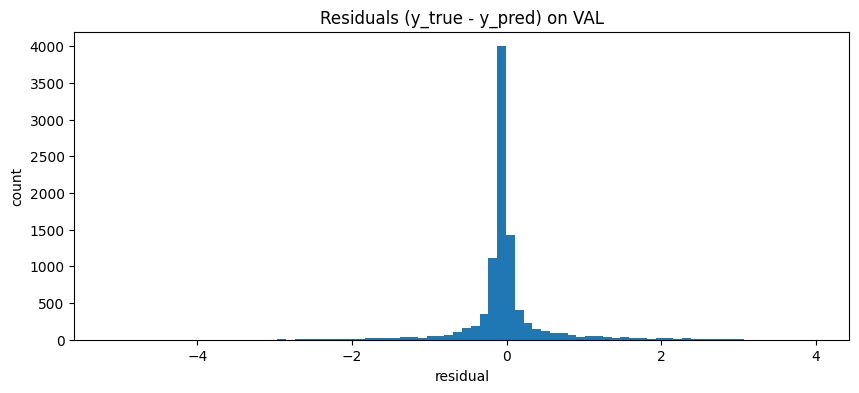

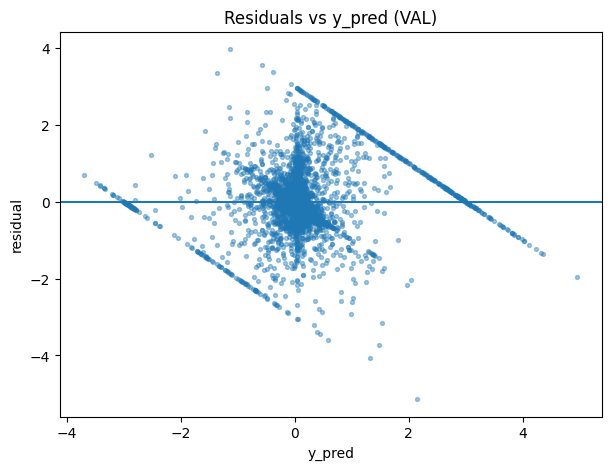

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_true = df_eval[TARGET].values
y_pred = df_eval["y_pred"].values
resid  = df_eval["residual"].values

mae  = mean_absolute_error(y_true, y_pred)
mse  = mean_squared_error(y_true, y_pred)
rmse = float(np.sqrt(mse))
r2   = r2_score(y_true, y_pred)

print(f"MAE:  {mae:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"R2:   {r2:.6f}")
print("Residual mean:", float(np.mean(resid)))
print("Residual std: ", float(np.std(resid)))

plt.figure(figsize=(10,4))
plt.hist(resid, bins=80)
plt.title("Residuals (y_true - y_pred) on VAL")
plt.xlabel("residual")
plt.ylabel("count")
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(y_pred, resid, s=8, alpha=0.4)
plt.axhline(0)
plt.title("Residuals vs y_pred (VAL)")
plt.xlabel("y_pred")
plt.ylabel("residual")
plt.show()
